# Flow-Matching + PPO Maze Solver (Chain-of-Sketch)

This notebook builds a small end-to-end pipeline for maze solving:
1. Generate random mazes and shortest-path traces.
2. Train a flow-matching sketcher to draw the path step by step.
3. Train a PPO agent that sees the maze + the sketch and navigates to the goal.

The default settings are intentionally small for quick MPS sanity checks.


In [1]:
%cd /Users/masha/Documents/visual-reasoning


/Users/masha/Documents/visual-reasoning


In [2]:
import math
import random
from collections import deque
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import gymnasium as gym

from stable_baselines3 import PPO


Utility helpers + small-run config.

In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = get_device()
print("Device:", DEVICE)

# Fast sanity-check config (small)
RUN_FAST = True
IMG_SIZE = 64
MAZE_CELLS = 9  # number of maze cells per side (grid is 2*MAZE_CELLS+1)

TRAIN_SAMPLES = 800 if not RUN_FAST else 250
TEST_SAMPLES = 200 if not RUN_FAST else 60
BATCH_SIZE = 32
EPOCHS = 50 if not RUN_FAST else 15
LR = 2e-4

PPO_STEPS = 40_000 if not RUN_FAST else 8_000
EVAL_EPISODES = 30 if not RUN_FAST else 8
MAX_EP_STEPS = 128


Device: mps


Maze generation, shortest path, and rasterization helpers.

In [4]:
def generate_maze(cells_w: int, cells_h: int, rng: random.Random) -> np.ndarray:
    """Generate a perfect maze with DFS backtracking. Returns grid with 1=wall, 0=free."""
    grid = np.ones((cells_h * 2 + 1, cells_w * 2 + 1), dtype=np.uint8)
    visited = np.zeros((cells_h, cells_w), dtype=bool)

    stack = [(0, 0)]
    visited[0, 0] = True
    grid[1, 1] = 0

    while stack:
        x, y = stack[-1]
        neighbors = []
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < cells_w and 0 <= ny < cells_h and not visited[ny, nx]:
                neighbors.append((nx, ny, dx, dy))
        if neighbors:
            nx, ny, dx, dy = rng.choice(neighbors)
            # carve wall between
            grid[y * 2 + 1 + dy, x * 2 + 1 + dx] = 0
            grid[ny * 2 + 1, nx * 2 + 1] = 0
            visited[ny, nx] = True
            stack.append((nx, ny))
        else:
            stack.pop()

    return grid


def bfs_shortest_path(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
    """Shortest path on grid (4-neighborhood). Returns list of (y, x)."""
    h, w = grid.shape
    q = deque([start])
    prev = {start: None}

    while q:
        y, x = q.popleft()
        if (y, x) == goal:
            break
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and grid[ny, nx] == 0:
                if (ny, nx) not in prev:
                    prev[(ny, nx)] = (y, x)
                    q.append((ny, nx))

    if goal not in prev:
        return []

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path


def path_to_trace(shape: Tuple[int, int], path: List[Tuple[int, int]], k: int) -> np.ndarray:
    trace = np.zeros(shape, dtype=np.float32)
    k = max(0, min(k, len(path) - 1))
    for y, x in path[: k + 1]:
        trace[y, x] = 1.0
    return trace


def one_hot_point(shape: Tuple[int, int], pos: Tuple[int, int]) -> np.ndarray:
    m = np.zeros(shape, dtype=np.float32)
    m[pos[0], pos[1]] = 1.0
    return m


def resize_nn(t: torch.Tensor, size: int) -> torch.Tensor:
    """Nearest-neighbor resize to IMG_SIZE. Accepts (H,W), (C,H,W), or (B,C,H,W)."""
    if t.dim() == 2:
        t = t.unsqueeze(0).unsqueeze(0)
    elif t.dim() == 3:
        t = t.unsqueeze(0)
    out = F.interpolate(t, size=(size, size), mode="nearest")
    return out.squeeze(0)


def build_cond(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int], img_size: int) -> torch.Tensor:
    walls = grid.astype(np.float32)
    start_ch = one_hot_point(grid.shape, start)
    goal_ch = one_hot_point(grid.shape, goal)
    cond = np.stack([walls, start_ch, goal_ch], axis=0)
    cond_t = torch.tensor(cond).float()
    return resize_nn(cond_t, img_size)


Dataset: random mazes with step-by-step traces (chain-of-sketch supervision).

In [5]:
class MazeTraceDataset(Dataset):
    def __init__(
        self,
        n_samples: int,
        maze_cells: int,
        img_size: int,
        seed: int = 0,
        min_path: int = 8,
    ):
        self.n = n_samples
        self.maze_cells = maze_cells
        self.img_size = img_size
        self.min_path = min_path
        self.rng = random.Random(seed)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        # generate maze + path
        grid = generate_maze(self.maze_cells, self.maze_cells, self.rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        path = bfs_shortest_path(grid, start, goal)
        if len(path) < self.min_path:
            # regenerate if path too short (rare for perfect mazes)
            return self.__getitem__(idx + 1)

        k = self.rng.randint(0, len(path) - 2)
        trace_t = path_to_trace(grid.shape, path, k)
        trace_next = path_to_trace(grid.shape, path, k + 1)
        delta = trace_next - trace_t
        t = k / max(1, len(path) - 1)

        cond = build_cond(grid, start, goal, self.img_size)
        trace_t = resize_nn(torch.tensor(trace_t).float(), self.img_size)
        delta = resize_nn(torch.tensor(delta).float(), self.img_size)

        return cond, trace_t, torch.tensor([t], dtype=torch.float32), delta


train_loader = DataLoader(
    MazeTraceDataset(TRAIN_SAMPLES, MAZE_CELLS, IMG_SIZE, seed=0),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    MazeTraceDataset(TEST_SAMPLES, MAZE_CELLS, IMG_SIZE, seed=123),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Flow-matching sketcher (UNet with time + maze conditioning).

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class MazeSketcher(nn.Module):
    def __init__(self, cond_ch: int = 3, flow_dim: int = 32):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4)
        )
        self.cond_encoder = nn.Sequential(
            nn.Conv2d(cond_ch, flow_dim, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(flow_dim, flow_dim * 2, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.cond_proj = nn.Linear(flow_dim * 2, flow_dim * 4)

        self.inc = DoubleConv(1 + cond_ch, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, trace_t: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        if t.dim() == 1:
            t = t.unsqueeze(1)
        t_emb = self.time_mlp(t)
        c = self.cond_encoder(cond).squeeze(-1).squeeze(-1)
        c_emb = self.cond_proj(c)
        global_cond = (t_emb + c_emb).unsqueeze(-1).unsqueeze(-1)

        x = torch.cat([trace_t, cond], dim=1)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)


Train the sketcher (small sanity run).

Epoch 01 | loss 0.07349
Epoch 05 | loss 0.00428
Epoch 10 | loss 0.00315
Epoch 15 | loss 0.00288


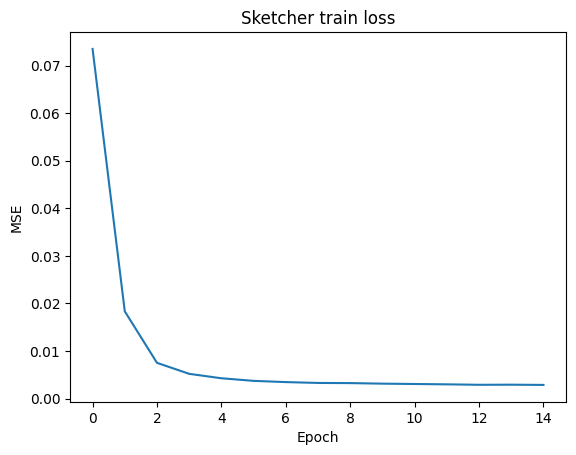

In [7]:
set_seed(0)

sketcher = MazeSketcher(cond_ch=3, flow_dim=32).to(DEVICE)
optimizer = torch.optim.AdamW(sketcher.parameters(), lr=LR)

train_losses = []
for epoch in range(EPOCHS):
    sketcher.train()
    epoch_loss = 0.0

    for cond, trace_t, t, delta in train_loader:
        cond = cond.to(DEVICE)
        trace_t = trace_t.to(DEVICE)
        t = t.to(DEVICE)
        delta = delta.to(DEVICE)

        pred = sketcher(trace_t, cond, t)
        loss = F.mse_loss(pred, delta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:02d} | loss {avg:.5f}")

plt.plot(train_losses)
plt.title("Sketcher train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

Visualize a chain-of-sketch rollout from the sketcher.

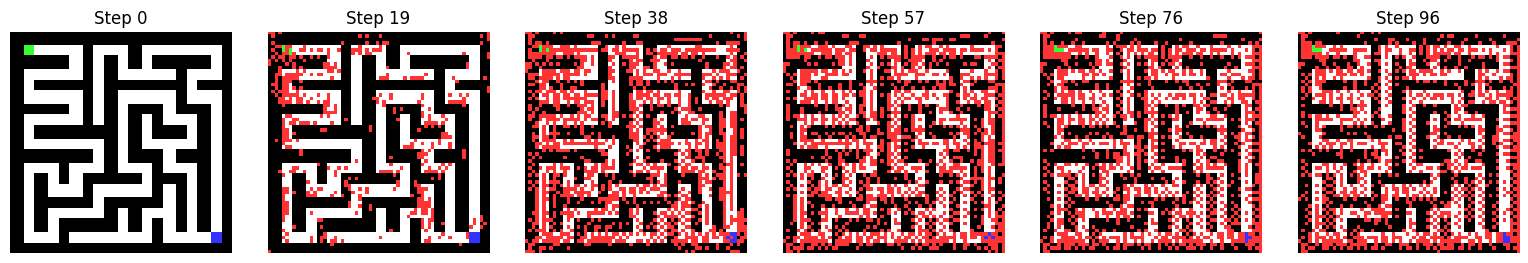

In [8]:
@torch.no_grad()
def rollout_sketch(model: nn.Module, cond: torch.Tensor, steps: int, device: torch.device):
    model.eval()
    b, _, h, w = cond.shape
    trace = torch.zeros((b, 1, h, w), device=device)
    frames = []
    for i in range(steps):
        t = torch.tensor([[i / max(1, steps - 1)]], device=device)
        delta = model(trace, cond, t)
        trace = (trace + delta).clamp(0.0, 1.0)
        frames.append(trace.detach().cpu())
    return frames


def compose_rgb(cond: np.ndarray, trace: Optional[np.ndarray] = None, agent: Optional[np.ndarray] = None) -> np.ndarray:
    # cond: (3, H, W) => walls, start, goal
    walls = cond[0]
    start = cond[1]
    goal = cond[2]
    h, w = walls.shape
    img = np.ones((h, w, 3), dtype=np.float32)
    img[walls > 0.5] = 0.0
    img[start > 0.5] = np.array([0.2, 1.0, 0.2])
    img[goal > 0.5] = np.array([0.2, 0.2, 1.0])
    if trace is not None:
        img[trace > 0.5] = np.array([1.0, 0.2, 0.2])
    if agent is not None:
        img[agent > 0.5] = np.array([1.0, 0.9, 0.1])
    return img


# sample maze + path
rng = random.Random(42)
grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
start = (1, 1)
goal = (grid.shape[0] - 2, grid.shape[1] - 2)
path = bfs_shortest_path(grid, start, goal)

cond_img = build_cond(grid, start, goal, IMG_SIZE)
cond_t = cond_img.unsqueeze(0).to(DEVICE)

frames = rollout_sketch(sketcher, cond_t, steps=len(path), device=DEVICE)

# show a few evenly spaced frames
idxs = np.linspace(0, len(frames) - 1, num=min(6, len(frames)), dtype=int)
fig, axes = plt.subplots(1, len(idxs), figsize=(2.6 * len(idxs), 2.6))
if len(idxs) == 1:
    axes = [axes]
for ax, i in zip(axes, idxs):
    trace = frames[i][0, 0].numpy()
    img = compose_rgb(cond_img.numpy(), trace=trace)
    ax.imshow(img)
    ax.set_title(f"Step {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


Gymnasium environment that feeds the FM sketch to PPO.

In [9]:
class MazeEnvFM(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        sketcher: nn.Module,
        maze_cells: int = 9,
        img_size: int = 64,
        max_steps: int = 128,
        device: Optional[torch.device] = None,
        seed: int = 0,
    ):
        super().__init__()
        self.sketcher = sketcher
        self.maze_cells = maze_cells
        self.img_size = img_size
        self.max_steps = max_steps
        self.device = device or get_device()
        self.rng = random.Random(seed)

        # channels: walls, start, goal, agent, sketch
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=(5, img_size, img_size), dtype=np.float32
        )
        self.action_space = gym.spaces.Discrete(4)  # up, down, left, right

        self.grid = None
        self.start = None
        self.goal = None
        self.pos = None
        self.step_idx = 0
        self.trace_frames = None
        self.cond_img = None
        self.prev_dist = None

    def _pos_channel(self) -> np.ndarray:
        pos_grid = one_hot_point(self.grid.shape, self.pos)
        pos_img = resize_nn(torch.tensor(pos_grid).float(), self.img_size).numpy()
        return pos_img

    def _obs(self) -> np.ndarray:
        trace = self.trace_frames[min(self.step_idx, len(self.trace_frames) - 1)]
        pos_ch = self._pos_channel()
        obs = np.concatenate([self.cond_img, pos_ch, trace], axis=0)
        return obs.astype(np.float32)

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = random.Random(seed)

        grid = generate_maze(self.maze_cells, self.maze_cells, self.rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        path = bfs_shortest_path(grid, start, goal)

        self.grid = grid
        self.start = start
        self.goal = goal
        self.pos = start
        self.step_idx = 0
        self.prev_dist = abs(start[0] - goal[0]) + abs(start[1] - goal[1])

        cond_img = build_cond(grid, start, goal, self.img_size)
        self.cond_img = cond_img.numpy()
        cond_t = cond_img.unsqueeze(0).to(self.device)

        with torch.no_grad():
            frames = rollout_sketch(self.sketcher, cond_t, steps=len(path), device=self.device)
        self.trace_frames = [f[0].numpy() for f in frames]  # (1, H, W) each

        return self._obs(), {"path_len": len(path)}

    def step(self, action: int):
        y, x = self.pos
        dy, dx = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}[int(action)]
        ny, nx = y + dy, x + dx

        reward = -0.01
        if 0 <= ny < self.grid.shape[0] and 0 <= nx < self.grid.shape[1] and self.grid[ny, nx] == 0:
            self.pos = (ny, nx)
        else:
            reward -= 0.05  # bump into wall

        dist = abs(self.pos[0] - self.goal[0]) + abs(self.pos[1] - self.goal[1])
        reward += (self.prev_dist - dist) * 0.02  # distance shaping
        self.prev_dist = dist

        terminated = (self.pos == self.goal)
        if terminated:
            reward += 1.0

        self.step_idx += 1
        truncated = self.step_idx >= self.max_steps

        info = {"pos": self.pos, "goal": self.goal}
        return self._obs(), float(reward), terminated, truncated, info


Train PPO using the FM sketch as a visual hint.

In [10]:
set_seed(0)

maze_env = MazeEnvFM(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=0,
)

model = PPO(
    "CnnPolicy",
    maze_env,
    verbose=1,
    device="mps" if DEVICE.type == "mps" else DEVICE,
    learning_rate=2e-4,
    policy_kwargs={"normalize_images": False},
)

model.learn(total_timesteps=PPO_STEPS)


Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 128      |
|    ep_rew_mean     | -4.61    |
| time/              |          |
|    fps             | 76       |
|    iterations      | 1        |
|    time_elapsed    | 26       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 128         |
|    ep_rew_mean          | -4.59       |
| time/                   |             |
|    fps                  | 77          |
|    iterations           | 2           |
|    time_elapsed         | 52          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014090413 |
|    clip_fraction        | 0.167       |
|    clip_range           | 0.2         |
|    entropy_loss   

Evaluate success rate on fresh mazes.

In [11]:
eval_env = MazeEnvFM(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=123,
)

success = 0
rewards = []
for _ in range(EVAL_EPISODES):
    obs, _ = eval_env.reset()
    terminated = False
    truncated = False
    ep_reward = 0.0

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env.step(int(action))
        ep_reward += reward

    rewards.append(ep_reward)
    if terminated:
        success += 1

print(f"Mean episode reward: {np.mean(rewards):.2f}")
print(f"Success rate: {success / EVAL_EPISODES:.2%}")


Mean episode reward: -7.38
Success rate: 0.00%


Visualize a rollout (maze + sketch + agent).

gifs/maze_ppo_fm_sample.gif


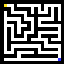

In [12]:
import imageio.v2 as imageio
import os
from IPython.display import Image, display


def render_env_frame(env: MazeEnvFM) -> np.ndarray:
    cond = env.cond_img
    trace = env.trace_frames[min(env.step_idx, len(env.trace_frames) - 1)][0]
    pos = env._pos_channel()[0]
    img = compose_rgb(cond, trace=trace, agent=pos)
    return (img * 255).astype(np.uint8)


def rollout_and_save_gif(
    env: MazeEnvFM,
    model: PPO,
    out_path: str = "gifs/maze_ppo_fm.gif",
    max_steps: int = 120,
    fps: int = 6,
):
    obs, _ = env.reset()
    frames = []
    for _ in range(max_steps):
        frames.append(render_env_frame(env))
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(int(action))
        if terminated or truncated:
            frames.append(render_env_frame(env))
            break

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    imageio.mimsave(out_path, frames, fps=fps)
    return out_path


gif_env = MazeEnvFM(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=999,
)

path = rollout_and_save_gif(gif_env, model, out_path="gifs/maze_ppo_fm_sample.gif")

print(path)
display(Image(filename=path))
